In [31]:
# !pip3 install scikit-learn matplotlib numpy

In [32]:
from sklearn.datasets import make_moons
from matplotlib import pyplot as plt 
import numpy as np 
import random 
%matplotlib inline

In [33]:
np.random.seed(1337)
random.seed(1337)

In [34]:
X, Y = make_moons(n_samples = 100, noise = 0.1)

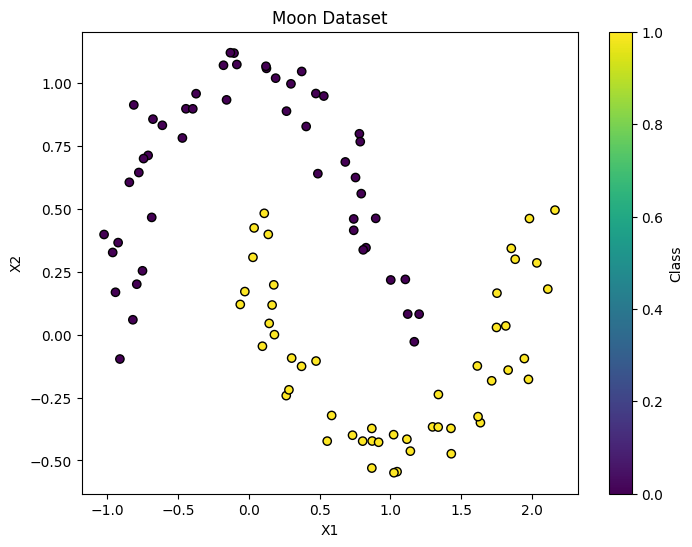

In [35]:
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=Y, cmap='viridis', edgecolors='k')
plt.xlabel('X1')
plt.ylabel('X2')
plt.title('Moon Dataset')
plt.colorbar(label='Class')
plt.show()

In [36]:
X.dtype

dtype('float64')

In [37]:
type(X)

numpy.ndarray

In [38]:
print(X[:10])

[[ 1.12211461  0.08147717]
 [-0.81882941  0.05879006]
 [ 1.61370966 -0.1246459 ]
 [-0.92300918  0.3652289 ]
 [ 0.14385146  0.04438005]
 [ 0.16447247  0.11738346]
 [ 1.33877062 -0.23800993]
 [ 0.87114861 -0.42271759]
 [ 1.83129946 -0.14104383]
 [ 0.4875712   0.63909283]]


In [39]:
print(Y[:10])

[0 0 1 0 1 1 1 1 1 0]


In [40]:
X.dtype, X[:2], X.shape

(dtype('float64'),
 array([[ 1.12211461,  0.08147717],
        [-0.81882941,  0.05879006]]),
 (100, 2))

In [41]:
Y.dtype, Y[:2], Y.shape

(dtype('int64'), array([0, 0]), (100,))

In [42]:
# x min ? max ? 
X.min(axis = 0), X.max(axis = 0)

(array([-1.02219391, -0.5486393 ]), array([2.16205598, 1.1193894 ]))

In [43]:
# 1st column min value: -1.02 
# 1st column max value: 2.16
# 2nd column min value: -0.54
# 2nd column max value: 1.119

In [44]:
Y.min(), Y.max()

(np.int64(0), np.int64(1))

In [45]:
xs = X.tolist()

In [46]:
len(xs)

100

In [47]:
# for x in xs: 
#     print(x)
#     print(len(x))
#     break
print(len(xs[0]))

2


In [48]:
ys = Y.tolist()

In [49]:
len(ys)

100

In [50]:
type(xs), type(ys)

(list, list)

In [51]:
import torch

In [52]:
xs = torch.tensor(xs)

In [53]:
print(xs[:10])

tensor([[ 1.1221,  0.0815],
        [-0.8188,  0.0588],
        [ 1.6137, -0.1246],
        [-0.9230,  0.3652],
        [ 0.1439,  0.0444],
        [ 0.1645,  0.1174],
        [ 1.3388, -0.2380],
        [ 0.8711, -0.4227],
        [ 1.8313, -0.1410],
        [ 0.4876,  0.6391]])


In [54]:
xs.dtype, xs.shape

(torch.float32, torch.Size([100, 2]))

In [55]:
ys = torch.tensor(ys)

In [56]:
ys.dtype, ys.shape

(torch.int64, torch.Size([100]))

In [57]:
import torch 
import torch.nn as nn

In [58]:
m = nn.Sequential(
    nn.Linear(2, 16), 
    nn.ReLU(), 
    nn.Linear(16, 16), 
    nn.ReLU(), 
    nn.Linear(16, 1)
)

In [59]:
ypreds = m(xs)

In [60]:
ypreds.dtype, ypreds.shape

(torch.float32, torch.Size([100, 1]))

In [61]:
import pprint
pprint.pprint(ypreds[:10])
pprint.pprint(ys[:10])

tensor([[ 0.0527],
        [ 0.1013],
        [ 0.0114],
        [ 0.1031],
        [ 0.1302],
        [ 0.1240],
        [ 0.0462],
        [ 0.0885],
        [-0.0107],
        [ 0.0566]], grad_fn=<SliceBackward0>)
tensor([0, 0, 1, 0, 1, 1, 1, 1, 1, 0])


In [62]:
ys.shape, ypreds.shape

(torch.Size([100]), torch.Size([100, 1]))

In [63]:
ys = ys.view(ys.shape[0], 1)

In [64]:
import pprint
pprint.pprint(ypreds[:10])
pprint.pprint(ys[:10])

tensor([[ 0.0527],
        [ 0.1013],
        [ 0.0114],
        [ 0.1031],
        [ 0.1302],
        [ 0.1240],
        [ 0.0462],
        [ 0.0885],
        [-0.0107],
        [ 0.0566]], grad_fn=<SliceBackward0>)
tensor([[0],
        [0],
        [1],
        [0],
        [1],
        [1],
        [1],
        [1],
        [1],
        [0]])


In [65]:
ys.shape, ypreds.shape

(torch.Size([100, 1]), torch.Size([100, 1]))

In [66]:
loss = (ypreds - ys).pow(2).mean()

In [67]:
loss

tensor(0.4499, grad_fn=<MeanBackward0>)

In [68]:
m.zero_grad()

In [69]:
loss.backward()

In [70]:
for p in m.parameters(): 
    p.data += (-0.0001) * p.grad

In [71]:
ypreds = m(xs) 
loss = (ypreds - ys).pow(2).mean()
loss

tensor(0.4496, grad_fn=<MeanBackward0>)

In [73]:
epoch = 10000
for i in range(epoch): 
    r_indx = torch.randperm(len(xs))[:50]
    batch_xs = xs[r_indx]
    batch_ys = ys[r_indx]
    
    ypreds = m(batch_xs)
    loss = (ypreds - batch_ys).pow(2).sum()
    if i % 100 == 0: 
        print("loss: ",loss, "step: ", i)

    m.zero_grad()

    loss.backward() 

    with torch.no_grad():
        for p in m.parameters():
            p.data += (-0.001) * p.grad

loss:  tensor(19.4602, grad_fn=<SumBackward0>) step:  0
loss:  tensor(5.9942, grad_fn=<SumBackward0>) step:  100
loss:  tensor(2.9749, grad_fn=<SumBackward0>) step:  200
loss:  tensor(3.5057, grad_fn=<SumBackward0>) step:  300
loss:  tensor(2.9619, grad_fn=<SumBackward0>) step:  400
loss:  tensor(3.0535, grad_fn=<SumBackward0>) step:  500
loss:  tensor(1.5215, grad_fn=<SumBackward0>) step:  600
loss:  tensor(1.2537, grad_fn=<SumBackward0>) step:  700
loss:  tensor(1.3198, grad_fn=<SumBackward0>) step:  800
loss:  tensor(0.9055, grad_fn=<SumBackward0>) step:  900
loss:  tensor(0.9833, grad_fn=<SumBackward0>) step:  1000
loss:  tensor(0.4891, grad_fn=<SumBackward0>) step:  1100
loss:  tensor(0.5757, grad_fn=<SumBackward0>) step:  1200
loss:  tensor(0.5066, grad_fn=<SumBackward0>) step:  1300
loss:  tensor(0.6797, grad_fn=<SumBackward0>) step:  1400
loss:  tensor(0.5645, grad_fn=<SumBackward0>) step:  1500
loss:  tensor(0.6115, grad_fn=<SumBackward0>) step:  1600
loss:  tensor(0.6341, gra

In [75]:
# import pickle 
# # weights dump after training
# weights = [p.data for p in m.parameters()] 
# with open("model_weights_torch_with_batch.pkl", 'wb') as f: 
#     pickle.dump(weights, f)


In [76]:
# load model weights 
import pickle
with open("model_weights_torch_with_batch.pkl", 'rb') as f: 
    weights = pickle.load(f)

In [77]:
for p, w in zip(m.parameters(), weights): 
    p.data = w

In [78]:
ypreds = [m(x)for x in xs]
loss = sum((ypred - y) ** 2 for ypred, y in zip(ypreds, ys))


In [79]:
print(loss)

tensor([0.1550], grad_fn=<AddBackward0>)


In [80]:
pprint.pprint(ypreds[:10])
pprint.pprint(ys[:10])

[tensor([0.0056], grad_fn=<ViewBackward0>),
 tensor([0.0086], grad_fn=<ViewBackward0>),
 tensor([0.9222], grad_fn=<ViewBackward0>),
 tensor([0.0018], grad_fn=<ViewBackward0>),
 tensor([1.0158], grad_fn=<ViewBackward0>),
 tensor([0.9986], grad_fn=<ViewBackward0>),
 tensor([0.8534], grad_fn=<ViewBackward0>),
 tensor([0.9876], grad_fn=<ViewBackward0>),
 tensor([1.0271], grad_fn=<ViewBackward0>),
 tensor([0.0368], grad_fn=<ViewBackward0>)]
tensor([[0],
        [0],
        [1],
        [0],
        [1],
        [1],
        [1],
        [1],
        [1],
        [0]])


(-1.7222875713140988, 2.027712428685901)

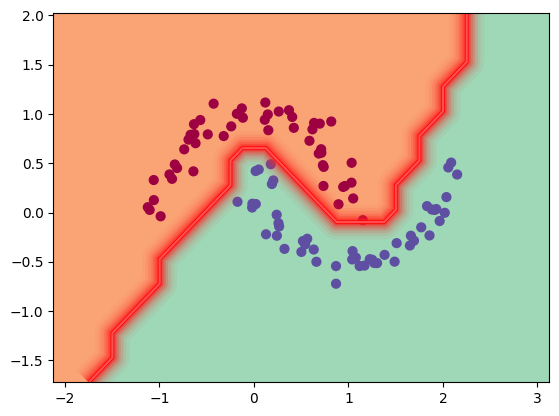

In [81]:
xs2, ys2 = make_moons(n_samples = 100, noise = 0.1)
h = 0.25
x_min, x_max = xs2[:, 0].min() - 1, xs2[:, 0].max() + 1
y_min, y_max = xs2[:, 1].min() - 1, xs2[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))
Xmesh = np.c_[xx.ravel(), yy.ravel()]
inputs = torch.tensor(Xmesh, dtype=torch.float32)
scores = m(inputs)
Z = (scores.data > 0.5).numpy()
Z = Z.reshape(xx.shape)

fig = plt.figure()
plt.contourf(xx, yy, Z, cmap=plt.cm.Spectral, alpha=0.8)

# Add glowing neon red decision boundary with enhanced glow
# Outer glow layers (more layers, wider spread, brighter colors)
for lw, alpha in [(25, 0.05), (20, 0.08), (16, 0.12), (12, 0.18), (9, 0.25), (6, 0.35), (4, 0.5)]:
    plt.contour(xx, yy, Z, levels=[0.5], colors=['#ff2222'], linewidths=lw, alpha=alpha)

# Core bright red line
contour = plt.contour(xx, yy, Z, levels=[0.5], colors=['#ff0000'], linewidths=2.5)
# Inner bright highlight
plt.contour(xx, yy, Z, levels=[0.5], colors=['#ff6666'], linewidths=1.5, alpha=0.8)

plt.scatter(xs2[:, 0], xs2[:, 1], c=ys2, s=40, cmap=plt.cm.Spectral)
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())